# Hierarchical Models with SBI and PyMC

This tutorial demonstrates how to use the **SBI-PyMC bridge** for hierarchical Bayesian inference.
We use the classic **Reed Frogs** example from [Statistical Rethinking](https://xcelab.net/rm/statistical-rethinking/),
which models tadpole survival across multiple experimental tanks.

## Tutorial Overview

We validate the SBI-PyMC bridge by comparing:
1. **Standard PyMC** with the true Binomial likelihood
2. **SBI-PyMC** with a neural likelihood estimator (NLE)

Both should produce matching posteriors, validating our bridge implementation.

### The Scientific Problem

The original experiment ([Vonesh & Bolker, 2005](https://esajournals.onlinelibrary.wiley.com/doi/10.1890/04-1524))
studied tadpole survival in 48 tanks with:
- **Varying densities**: 10, 25, or 35 tadpoles per tank (16 tanks each)
- **Predator presence**: yes/no
- **Size**: big/small

The goal is to estimate **tank-specific survival rates** while sharing information
across tanks through a hierarchical prior (partial pooling).

### Why Hierarchical Models?

- **Complete pooling**: Single global survival rate → underfits (ignores tank variation)
- **No pooling**: Independent rates per tank → overfits (ignores shared biology)
- **Partial pooling**: Tanks share a population prior → balances both

### Key Challenge: Varying Densities

Since tanks have different initial densities, we need an NLE that is **conditioned on both**:
- θ (survival parameter) - inferred
- density (experimental condition) - fixed/known

This is called a **density-conditioned NLE**: $p(x \mid \theta, \text{density})$

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import expit

from sbi.inference import NLE
from sbi.utils import BoxUniform
from sbi.utils.metrics import c2st
from sbi.utils.pymcutils import neural_likelihood_to_pymc

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Generate Reed Frogs Data

We generate synthetic data mimicking the original experiment:
- 48 tanks in a 2×2×3 factorial design
- 16 tanks at each density level (10, 25, 35)
- 1 observation per tank (final survival count)

In [ ]:
# Experimental design (Vonesh & Bolker, 2005)
n_tanks = 48

# Balanced factorial: 16 tanks at each density
densities = np.array([10]*16 + [25]*16 + [35]*16)
np.random.shuffle(densities)  # Randomize tank assignment

# Predator presence (randomly assigned)
predator = np.random.binomial(1, 0.5, size=n_tanks)

# True hierarchical parameters
TRUE_ALPHA_BAR = 1.5      # Population mean survival (logit scale)
TRUE_SIGMA = 1.0          # Population std
TRUE_BETA_PRED = -1.5     # Predator effect (reduces survival)

# Generate tank-specific survival rates
true_alpha = np.random.normal(TRUE_ALPHA_BAR, TRUE_SIGMA, size=n_tanks)
true_logit_p = true_alpha + TRUE_BETA_PRED * predator
true_p = expit(true_logit_p)

# Simulate survival (Binomial) - 1 observation per tank
survived = np.random.binomial(densities, true_p)

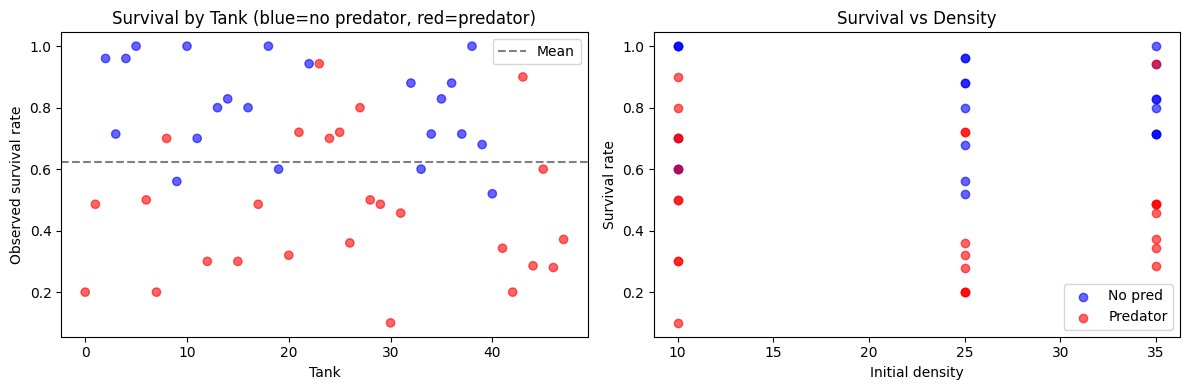

In [3]:
# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

observed_p = survived / densities
colors = ['blue' if p == 0 else 'red' for p in predator]

# Survival by tank
axes[0].scatter(range(n_tanks), observed_p, c=colors, alpha=0.6)
axes[0].axhline(y=np.mean(observed_p), color='gray', linestyle='--', label='Mean')
axes[0].set_xlabel('Tank')
axes[0].set_ylabel('Observed survival rate')
axes[0].set_title('Survival by Tank (blue=no predator, red=predator)')
axes[0].legend()

# Survival vs density
for dens in [10, 25, 35]:
    mask = densities == dens
    axes[1].scatter(densities[mask & (predator==0)], observed_p[mask & (predator==0)], 
                    c='blue', alpha=0.6, label='No pred' if dens == 10 else '')
    axes[1].scatter(densities[mask & (predator==1)], observed_p[mask & (predator==1)], 
                    c='red', alpha=0.6, label='Predator' if dens == 10 else '')
axes[1].set_xlabel('Initial density')
axes[1].set_ylabel('Survival rate')
axes[1].set_title('Survival vs Density')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Model Structure

$$
\begin{align}
S_i &\sim \text{Binomial}(D_i, p_i) \\
\text{logit}(p_i) &= \alpha_{\text{tank}[i]} + \beta_P \cdot \text{predator}_i \\
\alpha_{\text{tank}} &\sim \text{Normal}(\bar{\alpha}, \sigma) \\
\bar{\alpha} &\sim \text{Normal}(0, 1.5) \\
\sigma &\sim \text{Exponential}(1) \\
\beta_P &\sim \text{Normal}(0, 1)
\end{align}
$$

Where $D_i$ is the initial density (10, 25, or 35) for tank $i$.

## 1. Standard PyMC Model (True Likelihood)

First, we build the model using PyMC's native Binomial likelihood.

In [ ]:
coords = {"tank": np.arange(n_tanks)}

with pm.Model(coords=coords) as pymc_true_model:
    # Hyperpriors
    alpha_bar = pm.Normal("alpha_bar", mu=0, sigma=1.5)
    sigma = pm.Exponential("sigma", 1)
    
    # Predator effect
    beta_pred = pm.Normal("beta_pred", mu=0, sigma=1)
    
    # Tank-level intercepts (non-centered parameterization)
    z = pm.Normal("z", mu=0, sigma=1, dims="tank")
    alpha = pm.Deterministic("alpha", alpha_bar + z * sigma, dims="tank")
    
    # Linear model
    logit_p = alpha + beta_pred * predator
    p = pm.Deterministic("p", pm.math.invlogit(logit_p), dims="tank")
    
    # Binomial likelihood with VARYING densities
    S = pm.Binomial("S", n=densities, p=p, observed=survived, dims="tank")

In [5]:
# Sample from the true PyMC model
with pymc_true_model:
    trace_true = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=42,
        progressbar=True,
    )

az.summary(trace_true, var_names=["alpha_bar", "sigma", "beta_pred"])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha_bar, sigma, beta_pred, z]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_bar,1.506,0.237,1.073,1.967,0.004,0.003,3591.0,4842.0,1.0
sigma,0.956,0.156,0.677,1.249,0.003,0.002,2759.0,3829.0,1.0
beta_pred,-1.565,0.310,-2.144,-0.988,0.005,0.004,3350.0,4497.0,1.0


## 2. Train Density-Conditioned NLE

Since tanks have different densities, we train an NLE conditioned on **both** θ and density:

$$p(x \mid \theta, \text{density})$$

This single NLE works for any density value (amortized over densities).

In [ ]:
def binomial_simulator_with_density(theta_density: torch.Tensor) -> torch.Tensor:
    """
    Simulate tadpole survival conditioned on BOTH theta AND density.
    
    Args:
        theta_density: Combined input, shape (batch, 2)
                      - theta_density[:, 0] = logit survival probability
                      - theta_density[:, 1] = initial density
    
    Returns:
        Number of survivors, shape (batch, 1)
    """
    theta = theta_density[:, 0:1]
    density = theta_density[:, 1:2]
    
    p = torch.sigmoid(theta)
    density_int = density.round().long()
    survived = torch.distributions.Binomial(density_int.float(), p).sample()
    
    return survived

In [ ]:
# Generate training data with varying densities
n_sims = 50000
possible_densities = [10, 25, 35]

# Sample theta uniformly
theta_train = torch.rand(n_sims, 1) * 8.0 - 4.0  # [-4, 4]

# Sample density uniformly from the three values
density_indices = torch.randint(0, len(possible_densities), (n_sims, 1))
density_train = torch.tensor([possible_densities[i] for i in density_indices]).float().unsqueeze(1)

# Combine: (theta, density)
theta_density_train = torch.cat([theta_train, density_train], dim=1)

# Simulate
x_train = binomial_simulator_with_density(theta_density_train)

In [ ]:
# Train density-conditioned NLE
prior = BoxUniform(
    low=torch.tensor([-4.0, 10.0]),   # theta_min, density_min
    high=torch.tensor([4.0, 35.0]),   # theta_max, density_max
)

inference = NLE(prior=prior, density_estimator="maf")
inference.append_simulations(theta_density_train, x_train)
likelihood_nn = inference.train(training_batch_size=1024)

## 3. SBI-PyMC Bridge: Hierarchical Model with NLE

Now we use the density-conditioned NLE in a PyMC hierarchical model.

The key insight is that we pass **both** the inferred θ **and** the fixed density to the NLE:
- θ (logit survival) - varies during MCMC
- density - fixed per tank (known experimental condition)

We use `num_trials=1` and `num_subjects=48` for vectorized evaluation.

In [ ]:
# Prepare observed data: shape (num_trials=1, num_subjects=48, event_dim=1)
x_observed = survived.reshape(1, n_tanks, 1).astype(np.float32)

# Fixed densities as a constant tensor: shape (n_tanks, 1)
densities_pt = pt.as_tensor_variable(densities.astype(np.float32).reshape(-1, 1))

In [ ]:
with pm.Model(coords=coords) as pymc_nle_model:
    # Hyperpriors (same as true model)
    alpha_bar = pm.Normal("alpha_bar", mu=0, sigma=1.5)
    sigma = pm.Exponential("sigma", 1)
    beta_pred = pm.Normal("beta_pred", mu=0, sigma=1)
    
    # Tank-level intercepts (non-centered)
    z = pm.Normal("z", mu=0, sigma=1, dims="tank")
    alpha = pm.Deterministic("alpha", alpha_bar + z * sigma, dims="tank")
    
    # Compute logit_p for each tank: shape (n_tanks,)
    logit_p = alpha + beta_pred * predator
    
    # Create conditioning tensor: [theta, density] for each tank
    theta_col = logit_p.dimshuffle(0, 'x')  # (n_tanks, 1)
    theta_density = pt.concatenate([theta_col, densities_pt], axis=1)  # (n_tanks, 2)
    
    # Single VECTORIZED likelihood call for all 48 tanks
    neural_likelihood_to_pymc(
        likelihood_nn=likelihood_nn,
        theta=theta_density,  # 2D: [theta, density]
        observed=x_observed,
        name="x",
        num_trials=1,
        num_subjects=n_tanks,
    )

In [12]:
# Sample from the NLE-based model
with pymc_nle_model:
    trace_nle = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=42,
        progressbar=True,
    )

az.summary(trace_nle, var_names=["alpha_bar", "sigma", "beta_pred"])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha_bar, sigma, beta_pred, z]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 206 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_bar,1.517,0.239,1.070,1.959,0.005,0.003,2785.0,4211.0,1.0
sigma,0.964,0.166,0.665,1.280,0.004,0.002,2252.0,3396.0,1.0
beta_pred,-1.557,0.309,-2.127,-0.963,0.005,0.003,3191.0,4675.0,1.0


### MCMC Diagnostics

Before comparing posteriors, we verify sampling quality:
- **R-hat**: Should be < 1.01 for convergence
- **ESS**: Effective sample size (higher is better)
- **Divergences**: Indicate regions where the sampler struggled

In [ ]:
# MCMC diagnostics for both models
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# R-hat comparison
rhat_true = az.rhat(trace_true)
rhat_nle = az.rhat(trace_nle)
var_names = ["alpha_bar", "sigma", "beta_pred"]
rhat_true_vals = [rhat_true[v].item() for v in var_names]
rhat_nle_vals = [rhat_nle[v].item() for v in var_names]

x_pos = np.arange(len(var_names))
axes[0, 0].bar(x_pos - 0.15, rhat_true_vals, 0.3, label='PyMC (true)', alpha=0.7)
axes[0, 0].bar(x_pos + 0.15, rhat_nle_vals, 0.3, label='SBI-PyMC', alpha=0.7)
axes[0, 0].axhline(1.01, color='red', linestyle='--', label='Threshold (1.01)')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(var_names)
axes[0, 0].set_ylabel("R-hat")
axes[0, 0].set_title("Convergence (R-hat)")
axes[0, 0].set_ylim(0.99, 1.02)
axes[0, 0].legend(fontsize=8)

# ESS comparison
ess_true = az.ess(trace_true)
ess_nle = az.ess(trace_nle)
ess_true_vals = [ess_true[v].item() for v in var_names]
ess_nle_vals = [ess_nle[v].item() for v in var_names]

axes[0, 1].bar(x_pos - 0.15, ess_true_vals, 0.3, label='PyMC (true)', alpha=0.7)
axes[0, 1].bar(x_pos + 0.15, ess_nle_vals, 0.3, label='SBI-PyMC', alpha=0.7)
axes[0, 1].axhline(400, color='orange', linestyle='--', label='Min (400)')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(var_names)
axes[0, 1].set_ylabel("ESS (bulk)")
axes[0, 1].set_title("Effective Sample Size")
axes[0, 1].legend(fontsize=8)

# Divergences for SBI-PyMC
n_div = trace_nle.sample_stats.diverging.sum().item()
divergent = trace_nle.sample_stats.diverging.values.flatten()
alpha_bar_samples = trace_nle.posterior["alpha_bar"].values.flatten()
sigma_samples = trace_nle.posterior["sigma"].values.flatten()

axes[1, 0].scatter(alpha_bar_samples[~divergent], sigma_samples[~divergent], 
                   alpha=0.1, s=5, c='blue', label='Normal')
if divergent.any():
    axes[1, 0].scatter(alpha_bar_samples[divergent], sigma_samples[divergent], 
                       c='red', s=20, marker='x', label=f'Divergent ({n_div})')
axes[1, 0].set_xlabel("alpha_bar")
axes[1, 0].set_ylabel("sigma")
axes[1, 0].set_title(f"SBI-PyMC: Divergences ({n_div})")
axes[1, 0].legend(fontsize=8)

# Energy diagnostic
az.plot_energy(trace_nle, ax=axes[1, 1])
axes[1, 1].set_title("SBI-PyMC: Energy (BFMI)")

plt.tight_layout()
plt.show()

## 4. Compare Posteriors: PyMC vs SBI-PyMC

We validate the bridge by comparing the posterior distributions.

In [ ]:
def extract_samples(trace, var_names):
    """Extract and flatten posterior samples."""
    samples = [trace.posterior[var].values.reshape(-1) for var in var_names]
    return np.column_stack(samples)

vars_to_compare = ["alpha_bar", "sigma", "beta_pred"]

samples_true = extract_samples(trace_true, vars_to_compare)
samples_nle = extract_samples(trace_nle, vars_to_compare)

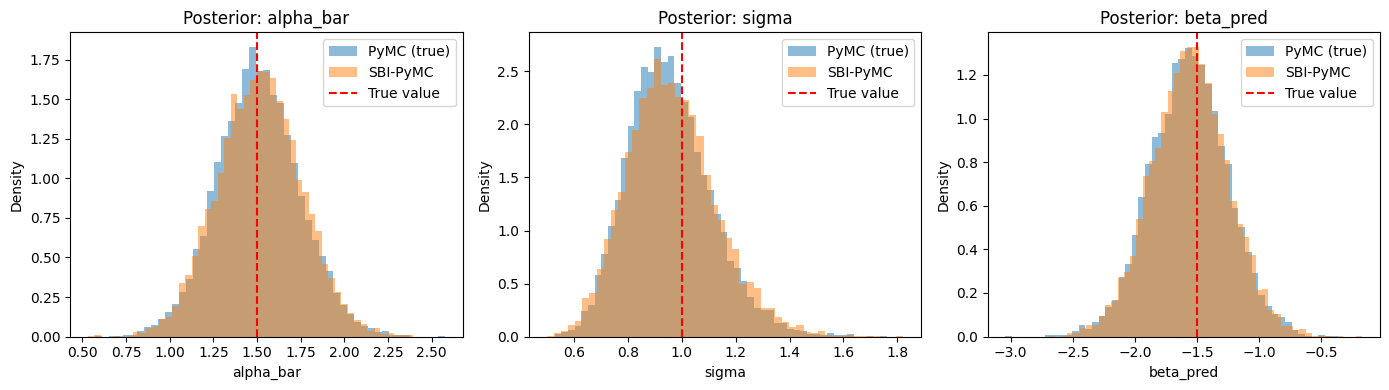

In [14]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, var) in enumerate(zip(axes, vars_to_compare)):
    ax.hist(samples_true[:, i], bins=50, alpha=0.5, density=True, label='PyMC (true)')
    ax.hist(samples_nle[:, i], bins=50, alpha=0.5, density=True, label='SBI-PyMC')
    ax.axvline(x=[TRUE_ALPHA_BAR, TRUE_SIGMA, TRUE_BETA_PRED][i], 
               color='red', linestyle='--', label='True value')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_title(f'Posterior: {var}')

plt.tight_layout()
plt.show()

In [ ]:
c2st_score = c2st(
    torch.from_numpy(samples_true).float(),
    torch.from_numpy(samples_nle).float(),
)

print(f"C2ST score: {c2st_score.mean():.3f}")
print("(C2ST ≈ 0.5 indicates indistinguishable distributions)")

C2ST for tank-level alphas: 0.620


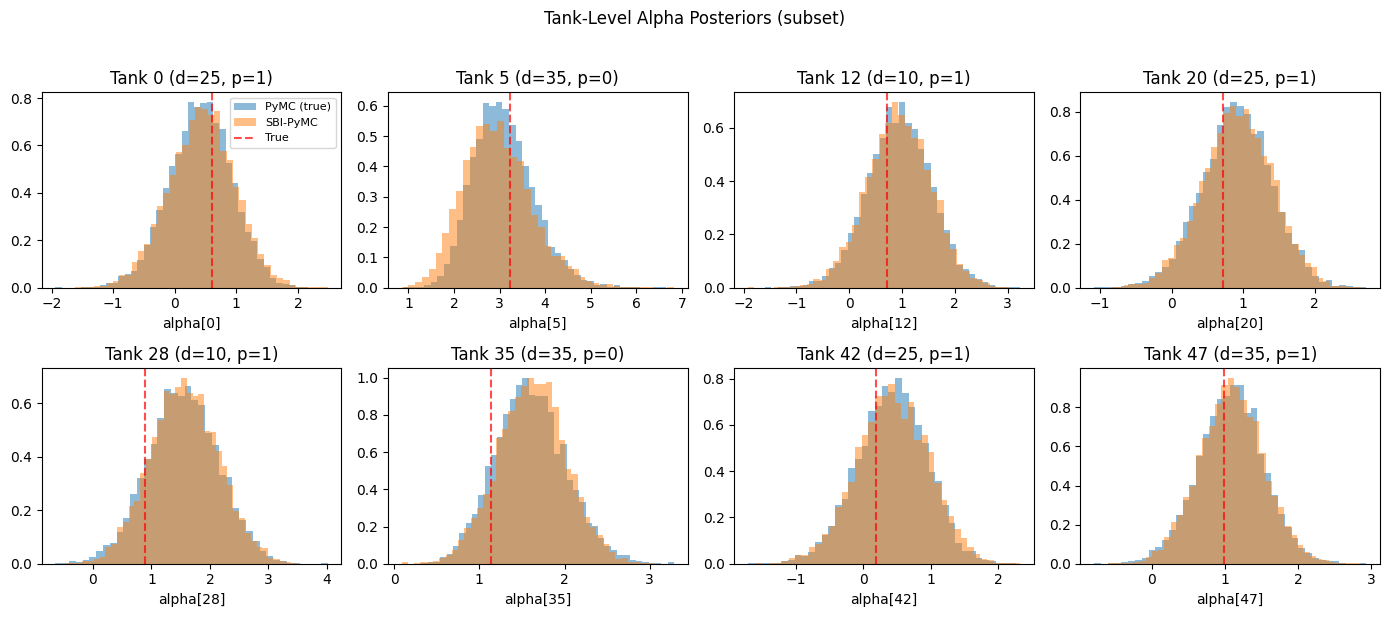

In [17]:
# Compare tank-level alpha posteriors
alpha_true = trace_true.posterior["alpha"].values.reshape(-1, n_tanks)  # (samples, tanks)
alpha_nle = trace_nle.posterior["alpha"].values.reshape(-1, n_tanks)

# C2ST for all alpha parameters combined
c2st_alpha = c2st(
    torch.from_numpy(alpha_true).float(),
    torch.from_numpy(alpha_nle).float(),
)
print(f"C2ST for tank-level alphas: {c2st_alpha.mean():.3f}")

# Visualize a subset of tank alphas
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
sample_tanks = [0, 5, 12, 20, 28, 35, 42, 47]  # Spread across tanks

for ax, tank_idx in zip(axes.flat, sample_tanks):
    ax.hist(alpha_true[:, tank_idx], bins=40, alpha=0.5, density=True, label='PyMC (true)')
    ax.hist(alpha_nle[:, tank_idx], bins=40, alpha=0.5, density=True, label='SBI-PyMC')
    ax.axvline(true_alpha[tank_idx], color='red', linestyle='--', alpha=0.7, label='True')
    ax.set_xlabel(f'alpha[{tank_idx}]')
    ax.set_title(f'Tank {tank_idx} (d={densities[tank_idx]}, p={predator[tank_idx]})')
    if tank_idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Tank-Level Alpha Posteriors (subset)', y=1.02)
plt.tight_layout()
plt.show()

### Posterior Predictive Checks

A key validation is **posterior predictive checking**: can our model reproduce the observed data?

We sample from the posterior and simulate new observations, then compare to the actual survival counts.

In [18]:
# Generate posterior predictive samples
# For the true model, we can use PyMC's posterior_predictive
with pymc_true_model:
    ppc_true = pm.sample_posterior_predictive(trace_true, var_names=["S"], random_seed=42)

# For NLE model, we simulate from the Binomial using the posterior alpha samples
# Extract posterior samples
alpha_bar_samples = trace_nle.posterior["alpha_bar"].values.flatten()
sigma_samples = trace_nle.posterior["sigma"].values.flatten()
beta_pred_samples = trace_nle.posterior["beta_pred"].values.flatten()
z_samples = trace_nle.posterior["z"].values.reshape(-1, n_tanks)

# Compute alpha and p for each sample
alpha_samples = alpha_bar_samples[:, None] + z_samples * sigma_samples[:, None]  # (samples, tanks)
logit_p_samples = alpha_samples + beta_pred_samples[:, None] * predator  # (samples, tanks)
p_samples = expit(logit_p_samples)  # (samples, tanks)

# Simulate survival counts
n_posterior_samples = len(alpha_bar_samples)
ppc_nle = np.zeros((n_posterior_samples, n_tanks))
for i in range(n_posterior_samples):
    ppc_nle[i] = np.random.binomial(densities, p_samples[i])

print(f"Posterior predictive samples: {ppc_nle.shape}")
print(f"True PPC shape: {ppc_true.posterior_predictive['S'].shape}")

Sampling: [S]


Output()

Posterior predictive samples: (8000, 48)
True PPC shape: (4, 2000, 48)


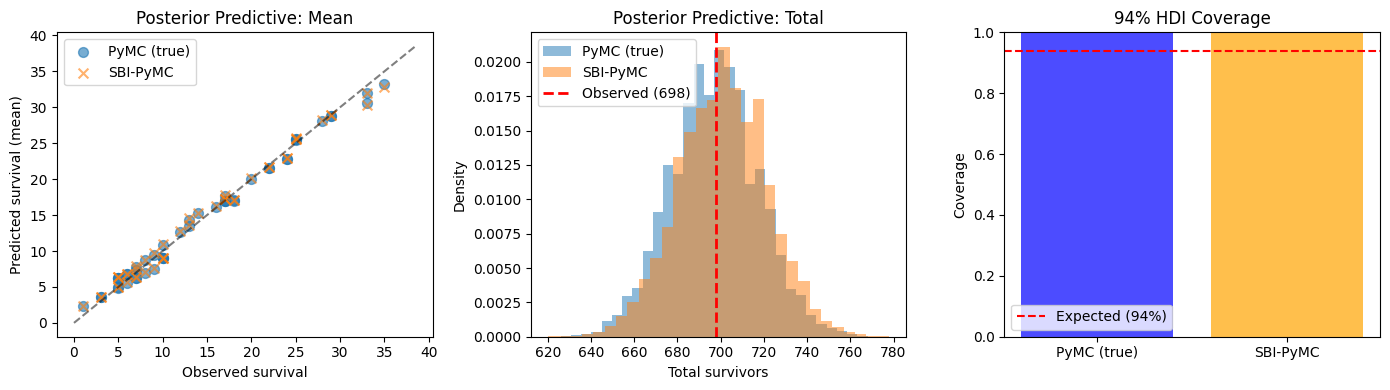

Coverage (94% HDI contains observed):
  PyMC (true): 100.0%
  SBI-PyMC:    100.0%


In [19]:
# Visualize posterior predictive checks
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Predicted vs observed (mean)
ppc_true_vals = ppc_true.posterior_predictive["S"].values.reshape(-1, n_tanks)
ppc_mean_true = ppc_true_vals.mean(axis=0)
ppc_mean_nle = ppc_nle.mean(axis=0)

ax = axes[0]
ax.scatter(survived, ppc_mean_true, alpha=0.6, label='PyMC (true)', s=50)
ax.scatter(survived, ppc_mean_nle, alpha=0.6, label='SBI-PyMC', marker='x', s=50)
ax.plot([0, max(survived)*1.1], [0, max(survived)*1.1], 'k--', alpha=0.5)
ax.set_xlabel('Observed survival')
ax.set_ylabel('Predicted survival (mean)')
ax.set_title('Posterior Predictive: Mean')
ax.legend()

# 2. Total survivors distribution
total_obs = survived.sum()
total_ppc_true = ppc_true_vals.sum(axis=1)
total_ppc_nle = ppc_nle.sum(axis=1)

ax = axes[1]
ax.hist(total_ppc_true, bins=30, alpha=0.5, density=True, label='PyMC (true)')
ax.hist(total_ppc_nle, bins=30, alpha=0.5, density=True, label='SBI-PyMC')
ax.axvline(total_obs, color='red', linestyle='--', linewidth=2, label=f'Observed ({total_obs})')
ax.set_xlabel('Total survivors')
ax.set_ylabel('Density')
ax.set_title('Posterior Predictive: Total')
ax.legend()

# 3. Coverage: 94% HDI contains observed?
def coverage(ppc_samples, observed, ci=0.94):
    """Fraction of observations within the posterior predictive CI."""
    lower = np.percentile(ppc_samples, (1-ci)/2*100, axis=0)
    upper = np.percentile(ppc_samples, (1+ci)/2*100, axis=0)
    return np.mean((observed >= lower) & (observed <= upper))

cov_true = coverage(ppc_true_vals, survived)
cov_nle = coverage(ppc_nle, survived)

ax = axes[2]
ax.bar(['PyMC (true)', 'SBI-PyMC'], [cov_true, cov_nle], color=['blue', 'orange'], alpha=0.7)
ax.axhline(0.94, color='red', linestyle='--', label='Expected (94%)')
ax.set_ylabel('Coverage')
ax.set_title('94% HDI Coverage')
ax.set_ylim(0, 1.0)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Coverage (94% HDI contains observed):")
print(f"  PyMC (true): {cov_true:.1%}")
print(f"  SBI-PyMC:    {cov_nle:.1%}")

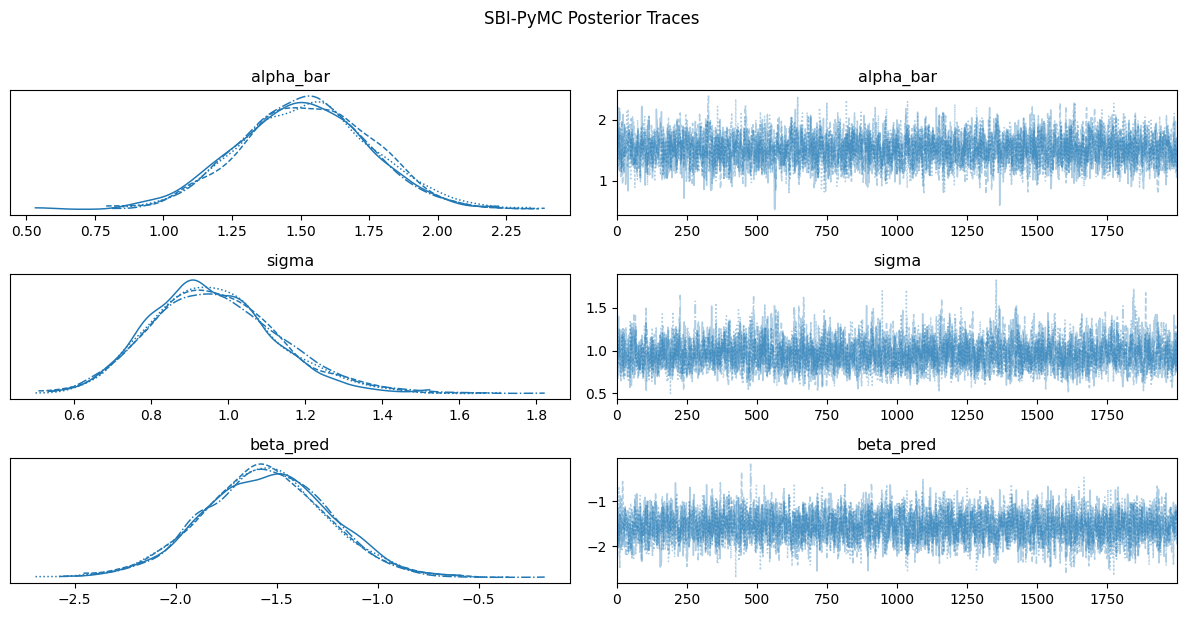

In [16]:
# Trace plots
az.plot_trace(trace_nle, var_names=["alpha_bar", "sigma", "beta_pred"])
plt.suptitle('SBI-PyMC Posterior Traces', y=1.02)
plt.tight_layout()
plt.show()

---

## Summary

### What We Demonstrated

1. **Density-conditioned NLE**: Trained a single NLE that works for varying tank densities (10, 25, 35)
2. **SBI-PyMC bridge**: Successfully integrated neural likelihoods with PyMC's hierarchical modeling
3. **Validation**: C2ST confirms posteriors match between true PyMC and SBI-PyMC

### Key Pattern: Experimental Conditions

When you have **known experimental conditions** that vary across observations:

```python
# 1. Train NLE with combined conditioning
theta_density_train = torch.cat([theta, density], dim=1)  # (batch, 2)
inference.append_simulations(theta_density_train, x_train)

# 2. In PyMC, concatenate inferred params with fixed conditions
theta_density = pt.concatenate([logit_p.dimshuffle(0, 'x'), densities_pt], axis=1)

# 3. Pass combined tensor to bridge
neural_likelihood_to_pymc(likelihood_nn, theta=theta_density, ...)
```

### When to Use This Approach

| Scenario | Recommendation |
|----------|----------------|
| Tractable likelihood | Use standard PyMC (faster, exact) |
| Intractable + hierarchical | Use **SBI-PyMC bridge** |
| Varying experimental conditions | Use **condition-aware NLE** (this tutorial) |

### Next Steps

See **Tutorial 18** for intractable likelihoods where SBI truly shines!

## References

- Vonesh, J.R. & Bolker, B.M. (2005). Compensatory larval responses shift trade-offs associated with predator-induced hatching plasticity. *Ecology* 86:1580-1591.
- McElreath, R. (2020). *Statistical Rethinking: A Bayesian Course with Examples in R and Stan*. CRC Press.
- [PyMC Multilevel Modeling Tutorial](https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/multilevel_modeling.html)
- [SBI Documentation](https://sbi.readthedocs.io/)